In [8]:
import geopandas as gpd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np

In [9]:
user = 'hubert'
file = glob.glob(f'segments/{user}/*.gpx')[0]
file

'segments/hubert/2025-09-22 184424__20250922_1844.gpx'

In [10]:
gpx_file = open(file, 'r')
gpx = gpxpy.parse(gpx_file)


In [11]:
def load_long_lat(user, n_segments=None):

    # Parsing an existing file:
    # -------------------------
    file = glob.glob(f'segments/{user}/*.gpx')[0]
    gpx_file = open(file, 'r')

    gpx = gpxpy.parse(gpx_file)
    track = []
    xs_tot = []
    ys_tot = []
    # xs_nc = []
    # ys_nc = []
    # cuts = []
    pts = 0
    for track_i in gpx.tracks:
        for s, segment in enumerate(track_i.segments):
            if (user == 'hubert') & (s == 1):
                continue
            if n_segments:
                if s >= n_segments:
                    return track, xs_tot, ys_tot
            xs = []
            ys = []
            for point in segment.points:
                ys.append(point.latitude)
                xs.append(point.longitude)
                # ys_tot.append(point.latitude)
                # xs_tot.append(point.longitude)
                pts += 1
                # print(f'Point at ({point.latitude},{point.longitude}) -> {point.elevation}')
            gdf_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(xs, ys), crs="EPSG:4326")
            gdf_points = gdf_points.to_crs(epsg=3857)
            xs_merc, ys_merc = zip(*[(p.x, p.y) for p in gdf_points.geometry])
            xs_merc = np.array(xs_merc)
            ys_merc = np.array(ys_merc)
            track.append({'lats': ys_merc,
                          'longs': xs_merc})
            xs_tot.extend(xs_merc)
            ys_tot.extend(ys_merc)
    return track, xs_tot, ys_tot


In [12]:
colors = {'hubert': 'cornflowerblue',
          'pa': 'tomato'}

In [13]:
20000 < np.inf

True

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
# Note: You need contextily installed (pip install contextily) for basemaps
import contextily as ctx 


def static_plot(track, xs_tot, ys_tot, user, fig, ax,
                x_min_global, x_max_global, y_min_global, y_max_global,
                pass_counts, is_first_pass, # Added is_first_pass
                step=1):
    lw = 2
    
    # 2a. Limits and Basemap
    x_min = np.min(xs_tot) - 500 
    x_max = np.max(xs_tot) + 500
    y_min = np.min(ys_tot) - 500 
    y_max = np.max(ys_tot) + 500
    x_min_global = min(x_min, x_min_global)
    x_max_global = max(x_max, x_max_global)
    y_min_global = min(y_min, y_min_global)
    y_max_global = max(y_max, y_max_global)
    
    ax.set_xlim(x_min_global, x_max_global)
    ax.set_ylim(y_min_global, y_max_global)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
    ax.set_axis_off()

    # 2b. Prepare Data: Get ALL segments
    s_start = 0
    all_segments_list = []
    all_colors_list = []
    
    for segment in track:
        xs = np.array(segment['longs'][::step])
        ys = np.array(segment['lats'][::step])
        segment_counts = pass_counts[s_start:s_start + len(xs)]
        segment_mask = is_first_pass[s_start:s_start + len(xs)] # Get mask for segment
        
        if len(xs) > 1:
            points = np.column_stack([xs, ys])
            segments = np.array([points[:-1], points[1:]]).transpose((1, 0, 2))
            
            # Use the mask of the starting point of the segment
            segments_list_mask = segment_mask[:-1] 

            all_segments_list.append(segments)
            all_colors_list.append(segment_counts[:-1])
            
        s_start += len(xs)

    if not all_segments_list:
        return fig, ax, x_min_global, x_max_global, y_min_global, y_max_global
    
    all_segments = np.concatenate(all_segments_list)
    all_colors = np.concatenate(all_colors_list)

    # 2c. Plot Base Layer (Continuous gray line)
    lc_base = LineCollection(all_segments, colors='grey', linewidth=1, alpha=0.3)
    ax.add_collection(lc_base)

    # 2d. Filter and Plot Highlight Layer (First Pass, Count > 1)
    # The mask needs to be combined across all segments
    all_mask = np.concatenate([is_first_pass[s_start-len(c)-1:s_start-1] for c in all_colors_list])

    # Filter based on: (a) is the first pass AND (b) has a count > 1
    highlight_mask = np.logical_and(all_mask, all_colors > 1)

    unique_high_segments = all_segments[highlight_mask]
    unique_high_colors = all_colors[highlight_mask]

    if len(unique_high_segments) > 0:
        min_count = 2
        max_count = np.max(unique_high_colors)
        
        if max_count >= min_count:
            norm = Normalize(vmin=min_count, vmax=max_count)
            cmap = plt.get_cmap('plasma')

            lc_high = LineCollection(unique_high_segments, cmap=cmap, norm=norm, 
                                     linewidth=lw, alpha=0.9)
            lc_high.set_array(unique_high_colors)

            line = ax.add_collection(lc_high)

            # Add Color Bar
            # cbar = fig.colorbar(line, ax=ax, orientation='vertical')
            # cbar.set_label('Pass Count (>1)', rotation=270, labelpad=15)
            # cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    fig.savefig(f'{user}_until_now_{step}.png', dpi=500)

    return fig, ax, x_min_global, x_max_global, y_min_global, y_max_global

In [32]:
def plot_track(users):
    fig, ax = plt.subplots(figsize=(8,8))
    x_min_global, x_max_global, y_min_global, y_max_global = np.inf, -np.inf, np.inf, -np.inf
    for user in users:
        track, xs_tot, ys_tot = load_long_lat(user, n_segments=None)
        pass_counts, is_first_pass = calculate_track_density_projected(ys_tot, xs_tot, radius_meters=10, time_excl_window=1,)
        fig, ax, x_min_global, x_max_global, y_min_global, y_max_global = static_plot(track, xs_tot, ys_tot, user, fig, ax,
            x_min_global, x_max_global, y_min_global, y_max_global,
            pass_counts, is_first_pass,
            step=1)
    plt.show()
    return xs_tot, ys_tot


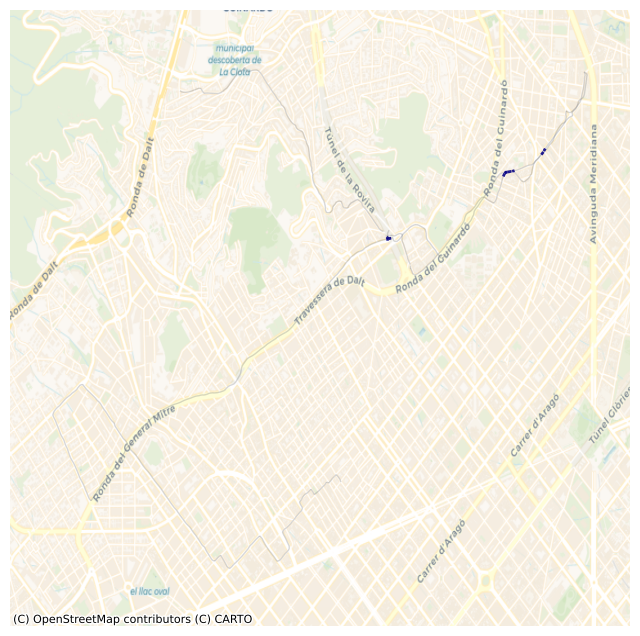

In [33]:
xs_tot, ys_tot = plot_track(['hubert'])

# Augmented version with the closer point path identification

In [2]:
import numpy as np
from scipy.spatial import KDTree

def calculate_track_density_projected(easting, northing, radius_meters=5.0, time_excl_window=10):
    
    if len(easting) != len(northing) or len(easting) == 0:
        return np.array([]), np.array([]) # Return two arrays now

    points = np.column_stack((easting, northing))
    tree = KDTree(points)
    search_radius = radius_meters
    n_points = len(points)
    
    pass_counts = np.zeros(n_points, dtype=int)
    # New array: True if this point is the first time we've passed this area
    is_first_pass = np.ones(n_points, dtype=bool) 
    
    for i in range(n_points):
        # 1. Density Calculation (Unchanged)
        neighbor_indices = tree.query_ball_point(points[i], r=search_radius)
        
        min_idx = max(0, i - time_excl_window)
        max_idx = min(n_points - 1, i + time_excl_window)
        exclusion_set = set(range(min_idx, max_idx + 1))
        
        final_count = 0
        for neighbor_idx in neighbor_indices:
            if neighbor_idx not in exclusion_set:
                final_count += 1
        pass_counts[i] = final_count + 1

        # 2. Redundancy Check (NEW LOGIC)
        # Find ALL neighbors that occurred EARLIER in time (j < i).
        # We don't need to re-query the tree, we just check the neighbor indices:
        earlier_neighbors = [j for j in neighbor_indices if j < i]
        
        if earlier_neighbors:
            # If ANY point was found earlier in this area, the current point 'i'
            # is a subsequent pass and is redundant for plotting the unique path.
            is_first_pass[i] = False
        
    return pass_counts, is_first_pass

# Minimal version without the mask, working

In [4]:
import numpy as np
from scipy.spatial import KDTree

def calculate_track_density_projected_minimal(easting, northing, radius_meters=5.0, time_excl_window=10):
    """
    Calculates the passage density for each point, assuming coordinates are in a 
    meter-based Projected Coordinate System (e.g., UTM Easting/Northing).

    :param easting: List or array of Easting coordinates (X).
    :param northing: List or array of Northing coordinates (Y).
    :param radius_meters: The spatial distance (in meters) for considering points as "same road".
    :param time_excl_window: The number of indices (points) before and after 
                             to exclude from the count.
    :return: A numpy array of pass counts for each point.
    """
    if len(easting) != len(northing) or len(easting) == 0:
        return np.array([])

    # Combine X and Y coordinates (Easting, Northing)
    points = np.column_stack((easting, northing))
    
    # --- 1. Build KD-Tree ---
    tree = KDTree(points)
    
    # The search radius 'r' is simply the required distance in meters.
    # The KD-Tree's Euclidean distance calculation is accurate here.
    search_radius = radius_meters
    
    # --- 2. Iterate, Query, and Filter ---
    n_points = len(points)
    pass_counts = np.zeros(n_points, dtype=int)
    
    for i in range(n_points):
        # Spatial Query: Find all point indices within the search_radius (5.0 meters)
        neighbor_indices = tree.query_ball_point(points[i], r=search_radius)
        
        # Time-based Exclusion: Define the window of indices to ignore
        min_idx = max(0, i - time_excl_window)
        max_idx = min(n_points - 1, i + time_excl_window)
        
        # We pre-calculate the exclusion set for fast lookups
        exclusion_set = set(range(min_idx, max_idx + 1))
        
        final_count = 0
        for neighbor_idx in neighbor_indices:
            # Only count the neighbor if it's NOT within the temporal exclusion window
            if neighbor_idx not in exclusion_set:
                final_count += 1
        
        # Add 1 to include the point itself as a "pass"
        pass_counts[i] = final_count + 1
        
    return pass_counts

In [65]:
pass_counts = calculate_track_density_projected(ys_tot, xs_tot, radius_meters=10.0, time_excl_window=3)


In [64]:
set(pass_counts)

{np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}

In [54]:
df_result

,latitude,longitude,time,pass_count
0,41.385105,2.173387,1970-01-01 00:00:00,2
1,41.385139,2.173449,1970-01-01 00:00:01,2
2,41.385187,2.173502,1970-01-01 00:00:02,2
3,41.385236,2.173531,1970-01-01 00:00:03,3
4,41.385258,2.173545,1970-01-01 00:00:04,3
...,...,...,...,...
495,41.385253,2.173558,1970-01-01 00:08:15,3
496,41.385222,2.173538,1970-01-01 00:08:16,3
497,41.385173,2.173487,1970-01-01 00:08:17,2
498,41.385134,2.173434,1970-01-01 00:08:18,2


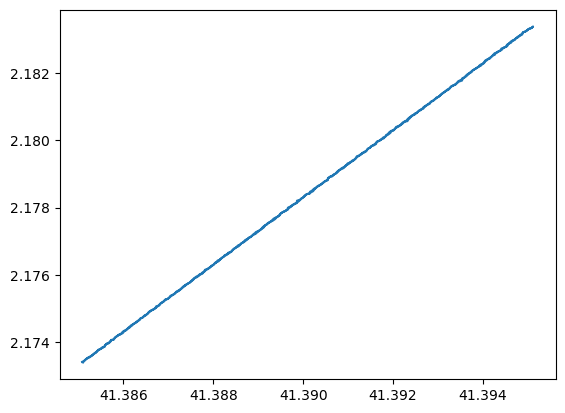

In [44]:
plt.plot(df_result['latitude'], df_result['longitude'])